# Session Engagement Prediction - Binary Classification

**Question**: Can we predict whether a user session will be highly engaged based on their browsing behavior?

## Workflow
1. Preparation Dataset (Original dataset loading, mapping values & session-level aggregation)
2. Feature Engineering (Categorical & Numerical)
3. Baseline Model (KNN)
4. Cross-Validation & GridSearchCV (Random Forest, KNN)
5. Ensemble Methods (Gradient Boosting)
6. Performance Comparison

---
# 1. Preparation Dataset

## Original dataset loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/raw/e-shop_clothing_2008.csv", sep=";")
df

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165469,2008,8,13,1,29,24024,2,B10,2,4,1,67,1,1
165470,2008,8,13,1,9,24025,1,A11,3,4,1,62,1,1
165471,2008,8,13,1,34,24026,1,A2,3,1,1,43,2,1
165472,2008,8,13,2,34,24026,3,C2,12,1,1,43,1,1


## Mapping values

This step involves decoding categorical variables using a metadata description file and integrating the decoded values into the main dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

In [4]:
df.shape

(165474, 14)

In [5]:
COUNTRY_MAP = {
    1: "Australia",
    2: "Austria",
    3: "Belgium",
    4: "British Virgin Islands",
    5: "Cayman Islands",
    6: "Christmas Island",
    7: "Croatia",
    8: "Cyprus",
    9: "Czech Republic",
    10: "Denmark",
    11: "Estonia",
    12: "unidentified",
    13: "Faroe Islands",
    14: "Finland",
    15: "France",
    16: "Germany",
    17: "Greece",
    18: "Hungary",
    19: "Iceland",
    20: "India",
    21: "Ireland",
    22: "Italy",
    23: "Latvia",
    24: "Lithuania",
    25: "Luxembourg",
    26: "Mexico",
    27: "Netherlands",
    28: "Norway",
    29: "Poland",
    30: "Portugal",
    31: "Romania",
    32: "Russia",
    33: "San Marino",
    34: "Slovakia",
    35: "Slovenia",
    36: "Spain",
    37: "Sweden",
    38: "Switzerland",
    39: "Ukraine",
    40: "United Arab Emirates",
    41: "United Kingdom",
    42: "USA",
    43: "biz",
    44: "com",
    45: "int",
    46: "net",
    47: "org",
}

In [6]:
df["country"] = df["country"].map(COUNTRY_MAP)
df['country'].value_counts(dropna=False)

country
Poland                    133963
Czech Republic             18003
Lithuania                   4091
net                         2522
com                         1385
Germany                      834
Ireland                      811
Slovakia                     716
United Kingdom               684
Belgium                      256
Netherlands                  227
unidentified                 210
USA                          170
Sweden                       163
Denmark                      152
Romania                      144
Italy                        144
Norway                       139
Switzerland                  137
France                       125
Estonia                      115
Luxembourg                    71
Austria                       58
Russia                        49
Latvia                        46
Finland                       43
Ukraine                       34
biz                           31
Iceland                       29
Greece                        23
Sp

In [7]:
MAIN_CATEGORY_MAP = {
    1: "trousers",
    2: "skirts",
    3: "blouses",
    4: "sale",
}
df["page 1 (main category)"] = df["page 1 (main category)"].map(MAIN_CATEGORY_MAP)

In [8]:
COLOUR_MAP = {
    1: "beige",
    2: "black",
    3: "blue",
    4: "brown",
    5: "burgundy",
    6: "gray",
    7: "green",
    8: "navy blue",
    9: "of many colors",
    10: "olive",
    11: "pink",
    12: "red",
    13: "violet",
    14: "white",
}
df["colour"] = df["colour"].map(COLOUR_MAP)

In [9]:
LOCATION_MAP = {
    1: "top left",
    2: "top in the middle",
    3: "top right",
    4: "bottom left",
    5: "bottom in the middle",
    6: "bottom right",
}
df["location"] = df["location"].map(LOCATION_MAP)

In [10]:
MODEL_PHOTOGRAPHY_MAP = {
    1: "en face",
    2: "profile",
}
df["model photography"] = df["model photography"].map(MODEL_PHOTOGRAPHY_MAP)

In [11]:
PRICE_2_MAP = {
    1: "above average",
    2: "below average",
}
df["price 2"] = df["price 2"].map(PRICE_2_MAP)

In [12]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,Poland,1,trousers,A13,beige,bottom in the middle,en face,28,below average,1
1,2008,4,1,2,Poland,1,trousers,A16,beige,bottom right,en face,33,below average,1
2,2008,4,1,3,Poland,1,skirts,B4,olive,top in the middle,en face,52,above average,1
3,2008,4,1,4,Poland,1,skirts,B17,gray,bottom right,profile,38,below average,1
4,2008,4,1,5,Poland,1,skirts,B8,brown,top right,profile,52,above average,1


In [13]:
new_columns = [
    'year',
    'month',
    'day',
    'order',
    'country',
    'session_id',
    'main_category',
    'clothing_model',
    'colour',
    'location',
    'model_photography',
    'price_usd',
    'price_vs_category_avg',
    'page'
]

df.columns = new_columns

In [14]:
df.head()

,year,month,day,order,country,session_id,main_category,clothing_model,colour,location,model_photography,price_usd,price_vs_category_avg,page
0,2008,4,1,1,Poland,1,trousers,A13,beige,bottom in the middle,en face,28,below average,1
1,2008,4,1,2,Poland,1,trousers,A16,beige,bottom right,en face,33,below average,1
2,2008,4,1,3,Poland,1,skirts,B4,olive,top in the middle,en face,52,above average,1
3,2008,4,1,4,Poland,1,skirts,B17,gray,bottom right,profile,38,below average,1
4,2008,4,1,5,Poland,1,skirts,B8,brown,top right,profile,52,above average,1


## Session-level aggregation (group by session_id)

In [15]:
# Unique sessions
df['session_id'].nunique()

24026

In [16]:
def get_mode(series):
    """Get the most frequent value of a series"""
    mode_result = series.mode()
    return mode_result.iloc[0] if len(mode_result) > 0 else series.iloc[0]

# Create session-level features through aggregation
session_df = df.groupby('session_id').agg(
    # For label creation
    total_clicks=('order', 'max'),

    # Categorical features (from original columns)
    country=('country', 'first'),
    first_category=('main_category', 'first'),
    last_category=('main_category', 'last'),
    dominant_category=('main_category', get_mode),
    dominant_colour=('colour', get_mode),
    first_location=('location', 'first'),
    dominant_location=('location', get_mode),
    photography_pref=('model_photography', get_mode),
    first_price_level=('price_vs_category_avg', 'first'),

    # Numerical features (aggregations)
    avg_price=('price_usd', 'mean'),
    min_price=('price_usd', 'min'),
    max_price=('price_usd', 'max'),
    price_std=('price_usd', 'std'),
    price_range=('price_usd', lambda x: x.max() - x.min()),

    category_diversity=('main_category', 'nunique'),
    colour_diversity=('colour', 'nunique'),
    unique_products=('clothing_model', 'nunique'),
    unique_pages=('page', 'nunique'),
    max_page_depth=('page', 'max'),
    avg_page=('page', 'mean'),

    # For derived features
    month=('month', 'first'),
    day=('day', 'first'),
    sale_clicks=('main_category', lambda x: (x == 'sale').sum()),
    blouse_clicks=('main_category', lambda x: (x == 'blouses').sum()),
    skirt_clicks=('main_category', lambda x: (x == 'skirts').sum()),
    trouser_clicks=('main_category', lambda x: (x == 'trousers').sum()),

    # Location-based
    top_position_clicks=('location', lambda x: x.str.startswith('top').sum()),

    # Photography
    en_face_clicks=('model_photography', lambda x: (x == 'en face').sum()),

    # Price level
    above_avg_price_clicks=('price_vs_category_avg', lambda x: (x == 'above average').sum()),
).reset_index()

print(f"Session-level shape: {session_df.shape}")

Session-level shape: (24026, 31)


In [17]:
session_df.head()

,session_id,total_clicks,country,first_category,last_category,dominant_category,dominant_colour,first_location,dominant_location,photography_pref,...,avg_page,month,day,sale_clicks,blouse_clicks,skirt_clicks,trouser_clicks,top_position_clicks,en_face_clicks,above_avg_price_clicks
0,1,9,Poland,trousers,sale,skirts,gray,bottom in the middle,bottom in the middle,profile,...,2.444444,4,1,2,2,3,2,4,4,5
1,2,10,Poland,skirts,sale,skirts,blue,bottom in the middle,bottom in the middle,en face,...,1.700000,4,1,3,0,5,2,5,9,8
2,3,6,Ireland,skirts,sale,blouses,brown,bottom right,bottom right,en face,...,1.666667,4,1,1,4,1,0,3,4,4
3,4,4,Ireland,trousers,blouses,blouses,black,bottom right,bottom right,en face,...,2.000000,4,1,0,2,0,2,3,4,2
4,5,1,Czech Republic,blouses,blouses,blouses,white,top left,top left,en face,...,2.000000,4,1,0,1,0,0,1,1,1


In [18]:
session_df.columns.tolist()

['session_id',
 'total_clicks',
 'country',
 'first_category',
 'last_category',
 'dominant_category',
 'dominant_colour',
 'first_location',
 'dominant_location',
 'photography_pref',
 'first_price_level',
 'avg_price',
 'min_price',
 'max_price',
 'price_std',
 'price_range',
 'category_diversity',
 'colour_diversity',
 'unique_products',
 'unique_pages',
 'max_page_depth',
 'avg_page',
 'month',
 'day',
 'sale_clicks',
 'blouse_clicks',
 'skirt_clicks',
 'trouser_clicks',
 'top_position_clicks',
 'en_face_clicks',
 'above_avg_price_clicks']

---
# 2. Feature Engineering

We work directly with the 31 columns from session-level aggregation. 
The key steps are:
1. Handle missing values (`price_std` is NaN for single-click sessions)
2. Create the **label** column from `total_clicks`
3. Encode categorical features using `OneHotEncoder` inside a pipeline (no extra columns added to `session_df`)
4. Scale numerical features using `StandardScaler`

In [19]:
# Handle NaN: price_std is NaN for single-click sessions
session_df['price_std'] = session_df['price_std'].fillna(0)

print(f"Missing values remaining: {session_df.isnull().sum().sum()}")

Missing values remaining: 0


## Label Creation

We define engagement based on a click threshold. A session with **>= 6 clicks** is labelled as **high engagement (1)**, otherwise **low engagement (0)**.

In [20]:
# Explore the distribution of total_clicks to pick a threshold
print("total_clicks distribution:")
print(session_df['total_clicks'].describe())

print("\nThreshold options:")
for t in [4, 5, 6, 7, 8, 10]:
    pos = (session_df['total_clicks'] >= t).sum()
    pct = pos / len(session_df) * 100
    print(f"  >= {t:2d} clicks: {pos:,} positive ({pct:.1f}%) | {len(session_df)-pos:,} negative ({100-pct:.1f}%)")

total_clicks distribution:
count    24026.000000
mean         6.887289
std          8.995161
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        195.000000
Name: total_clicks, dtype: float64

Threshold options:
  >=  4 clicks: 13,044 positive (54.3%) | 10,982 negative (45.7%)
  >=  5 clicks: 11,007 positive (45.8%) | 13,019 negative (54.2%)
  >=  6 clicks: 9,410 positive (39.2%) | 14,616 negative (60.8%)
  >=  7 clicks: 8,012 positive (33.3%) | 16,014 negative (66.7%)
  >=  8 clicks: 6,895 positive (28.7%) | 17,131 negative (71.3%)
  >= 10 clicks: 5,212 positive (21.7%) | 18,814 negative (78.3%)


Label distribution (threshold = 6 clicks):
label
0    14616
1     9410
Name: count, dtype: int64

Positive class ratio: 39.2%


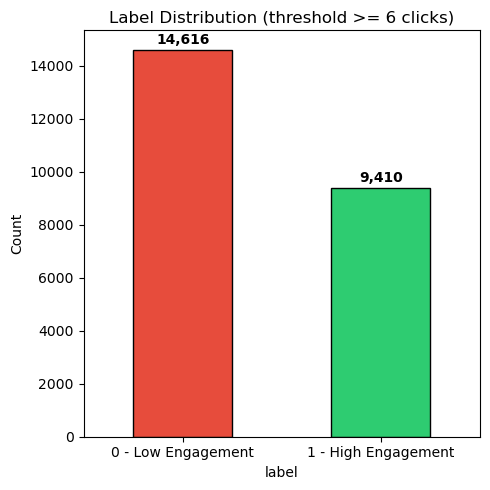

In [21]:
ENGAGEMENT_THRESHOLD = 6

session_df['label'] = (session_df['total_clicks'] >= ENGAGEMENT_THRESHOLD).astype(int)

print(f"Label distribution (threshold = {ENGAGEMENT_THRESHOLD} clicks):")
print(session_df['label'].value_counts())
print(f"\nPositive class ratio: {session_df['label'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 5))
session_df['label'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_xticklabels(['0 - Low Engagement', '1 - High Engagement'], rotation=0)
ax.set_ylabel('Count')
ax.set_title(f'Label Distribution (threshold >= {ENGAGEMENT_THRESHOLD} clicks)')
for i, v in enumerate(session_df['label'].value_counts().sort_index()):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Define Features & Preprocessing Pipeline

We use the existing 31 columns directly without adding derived columns to the dataframe. All transformations happen inside sklearn pipelines.

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
)

print("All imports ready.")

All imports ready.


In [23]:
# Categorical features: encoded with OneHotEncoder in the pipeline
categorical_features = [
    'country',
    'first_category',
    'last_category',
    'dominant_category',
    'dominant_colour',
    'first_location',
    'dominant_location',
    'photography_pref',
    'first_price_level',
]

# Numerical features: scaled with StandardScaler in the pipeline
numerical_features = [
    'avg_price',
    'min_price',
    'max_price',
    'price_std',
    'price_range',
    'category_diversity',
    'colour_diversity',
    'unique_products',
    'unique_pages',
    'max_page_depth',
    'avg_page',
    'month',
    'day',
    'sale_clicks',
    'blouse_clicks',
    'skirt_clicks',
    'trouser_clicks',
    'top_position_clicks',
    'en_face_clicks',
    'above_avg_price_clicks',
]

all_features = categorical_features + numerical_features

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features:   {len(numerical_features)}")
print(f"Total features:       {len(all_features)}")

Categorical features: 9
Numerical features:   20
Total features:       29


In [24]:
# Prepare X and y
X = session_df[all_features].copy()
y = session_df['label'].copy()

# Train / Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")

X_train: (19220, 29)
X_test:  (4806, 29)
y_train distribution:
label
0    11692
1     7528
Name: count, dtype: int64


In [25]:
# Preprocessing pipeline (used inside every model pipeline)
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features),
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


---
# 3. Baseline Model (KNN)

We use **K-Nearest Neighbors (KNN) with default parameters** as our baseline. KNN is a simple, non-parametric model that serves as a natural starting point. From initial testing it has the lowest accuracy among our candidate models, giving us a clear floor to improve upon with hyperparameter tuning and ensemble methods.

In [26]:
# Build baseline pipeline: KNN with default params (k=5)
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier()),
])

# Train
baseline_pipeline.fit(X_train, y_train)

# Predict
y_pred_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
print("="*60)
print("BASELINE MODEL: KNN (default parameters, k=5)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_base):.4f}")

BASELINE MODEL: KNN (default parameters, k=5)
Accuracy:  0.9345
Precision: 0.9505
Recall:    0.8783
F1-Score:  0.9130
ROC-AUC:   0.9747


In [27]:
# Store baseline metrics
baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_f1  = f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_prob_base)

results = []
results.append({
    'Model': 'KNN (Baseline)',
    'Accuracy': baseline_acc,
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1-Score': baseline_f1,
    'ROC-AUC': baseline_auc,
})

Classification Report:
                 precision    recall  f1-score   support

 Low Engagement       0.93      0.97      0.95      2924
High Engagement       0.95      0.88      0.91      1882

       accuracy                           0.93      4806
      macro avg       0.94      0.92      0.93      4806
   weighted avg       0.94      0.93      0.93      4806



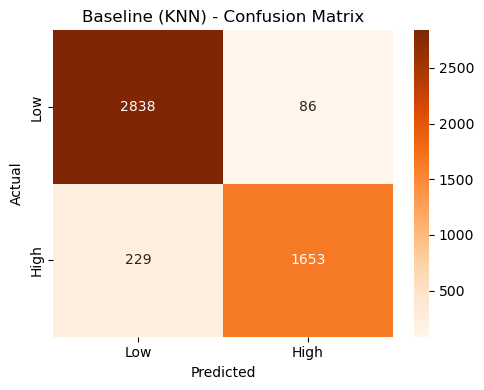

In [28]:
# Confusion matrix
print("Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Low Engagement', 'High Engagement']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Baseline (KNN) - Confusion Matrix')
plt.tight_layout()
plt.show()

In [29]:
# 5-fold cross-validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(baseline_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(baseline_pipeline, X_train, y_train, cv=cv, scoring='f1')
cv_auc = cross_val_score(baseline_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print("Baseline (KNN) 5-Fold Cross-Validation (training set):")
print(f"  Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std()*2:.4f})")
print(f"  F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std()*2:.4f})")
print(f"  ROC-AUC:  {cv_auc.mean():.4f} (+/- {cv_auc.std()*2:.4f})")

Baseline (KNN) 5-Fold Cross-Validation (training set):
  Accuracy: 0.9330 (+/- 0.0074)
  F1-Score: 0.9108 (+/- 0.0105)
  ROC-AUC:  0.9784 (+/- 0.0035)


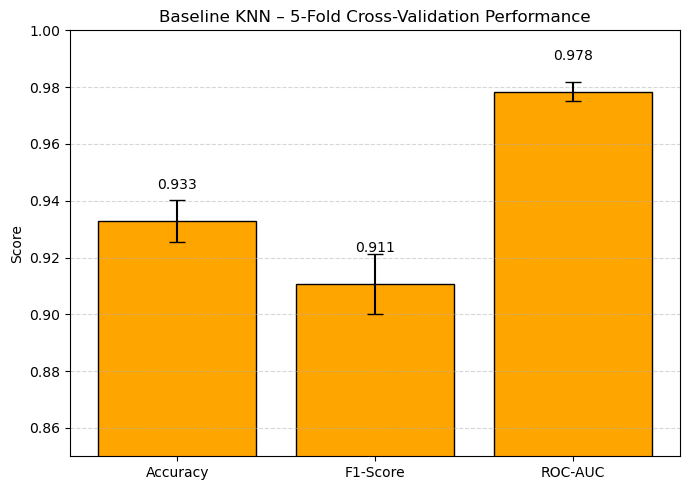

In [30]:
# Cross-validation results
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
means = [cv_acc.mean(), cv_f1.mean(), cv_auc.mean()]
stds  = [cv_acc.std()*2, cv_f1.std()*2, cv_auc.std()*2]  # ±2 std

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(metrics, means, yerr=stds, capsize=6, edgecolor='black', color='orange')

# Labels on bars
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width() / 2,
             mean + 0.01,
             f'{mean:.3f}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0.85, 1.0)
plt.ylabel('Score')
plt.title('Baseline KNN – 5-Fold Cross-Validation Performance')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('baseline_knn_cv_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 4. Cross-Validation & GridSearchCV

We apply **5-fold Stratified Cross-Validation** with **GridSearchCV** to tune hyperparameters for each model. Models evaluated:
- **Random Forest**
- **KNN** (tuned version of baseline)

In [31]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [32]:
# --- Random Forest GridSearchCV ---
print("GridSearchCV: Random Forest")

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
}

rf_search = GridSearchCV(rf_pipe, rf_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
rf_search.fit(X_train, y_train)

print(f"  Best params:    {rf_search.best_params_}")
print(f"  Best CV F1:     {rf_search.best_score_:.4f}")

y_pred_rf = rf_search.best_estimator_.predict(X_test)
y_prob_rf = rf_search.best_estimator_.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Model': 'Random Forest (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
}
results.append(rf_metrics)
print(f"  Test Accuracy:  {rf_metrics['Accuracy']:.4f}")
print(f"  Test F1:        {rf_metrics['F1-Score']:.4f}")
print(f"  Test AUC:       {rf_metrics['ROC-AUC']:.4f}")

GridSearchCV: Random Forest
Fitting 3 folds for each of 16 candidates, totalling 48 fits
  Best params:    {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
  Best CV F1:     0.9886
  Test Accuracy:  0.9896
  Test F1:        0.9866
  Test AUC:       0.9996


In [33]:
# --- KNN (Tuned) GridSearchCV ---
print("GridSearchCV: KNN (Tuned)")

knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier()),
])

knn_params = {
    'classifier__n_neighbors': [3, 5, 7, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean']
}

knn_search = GridSearchCV(knn_pipe, knn_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
knn_search.fit(X_train, y_train)

print(f"  Best params:    {knn_search.best_params_}")
print(f"  Best CV F1:     {knn_search.best_score_:.4f}")

y_pred_knn = knn_search.best_estimator_.predict(X_test)
y_prob_knn = knn_search.best_estimator_.predict_proba(X_test)[:, 1]

knn_metrics = {
    'Model': 'KNN (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn),
    'ROC-AUC': roc_auc_score(y_test, y_prob_knn),
}
results.append(knn_metrics)
print(f"  Test Accuracy:  {knn_metrics['Accuracy']:.4f}")
print(f"  Test F1:        {knn_metrics['F1-Score']:.4f}")
print(f"  Test AUC:       {knn_metrics['ROC-AUC']:.4f}")

GridSearchCV: KNN (Tuned)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
  Best params:    {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
  Best CV F1:     0.9169
  Test Accuracy:  0.9401
  Test F1:        0.9199
  Test AUC:       0.9859


---
# 5. Ensemble Methods

Ensemble methods combine multiple weak learners into a stronger model. We use:
- **Gradient Boosting**: sequentially fits trees on the residual errors of previous trees

Both are tuned with GridSearchCV + 5-fold CV.

In [34]:
# --- 5.1 Gradient Boosting GridSearchCV ---
print("GridSearchCV: Gradient Boosting")

gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42)),
])

gb_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.1, 0.2],
    'classifier__max_depth': [3, 5]
}

gb_search = GridSearchCV(gb_pipe, gb_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
gb_search.fit(X_train, y_train)

print(f"  Best params:    {gb_search.best_params_}")
print(f"  Best CV F1:     {gb_search.best_score_:.4f}")

y_pred_gb = gb_search.best_estimator_.predict(X_test)
y_prob_gb = gb_search.best_estimator_.predict_proba(X_test)[:, 1]

gb_metrics = {
    'Model': 'Gradient Boosting (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1-Score': f1_score(y_test, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_gb),
}
results.append(gb_metrics)
print(f"  Test Accuracy:  {gb_metrics['Accuracy']:.4f}")
print(f"  Test F1:        {gb_metrics['F1-Score']:.4f}")
print(f"  Test AUC:       {gb_metrics['ROC-AUC']:.4f}")

GridSearchCV: Gradient Boosting
Fitting 3 folds for each of 8 candidates, totalling 24 fits
  Best params:    {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
  Best CV F1:     0.9926
  Test Accuracy:  0.9952
  Test F1:        0.9939
  Test AUC:       1.0000


---
# 6. Performance Comparison

In [35]:
# Final results table
final_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)

# Compute improvement over baseline
final_df['F1 Improvement (%)'] = ((final_df['F1-Score'] - baseline_f1) / baseline_f1 * 100).round(2)

print("="*95)
print("FULL MODEL COMPARISON (sorted by F1-Score)")
print("="*95)
print(final_df.to_string(index=False))

FULL MODEL COMPARISON (sorted by F1-Score)
                    Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  F1 Improvement (%)
Gradient Boosting (Tuned)  0.995214   1.000000 0.987779  0.993852 0.999956                8.85
    Random Forest (Tuned)  0.989596   0.998911 0.974495  0.986552 0.999608                8.06
              KNN (Tuned)  0.940075   0.965537 0.878321  0.919866 0.985897                0.75
           KNN (Baseline)  0.934457   0.950546 0.878321  0.913007 0.974662                0.00


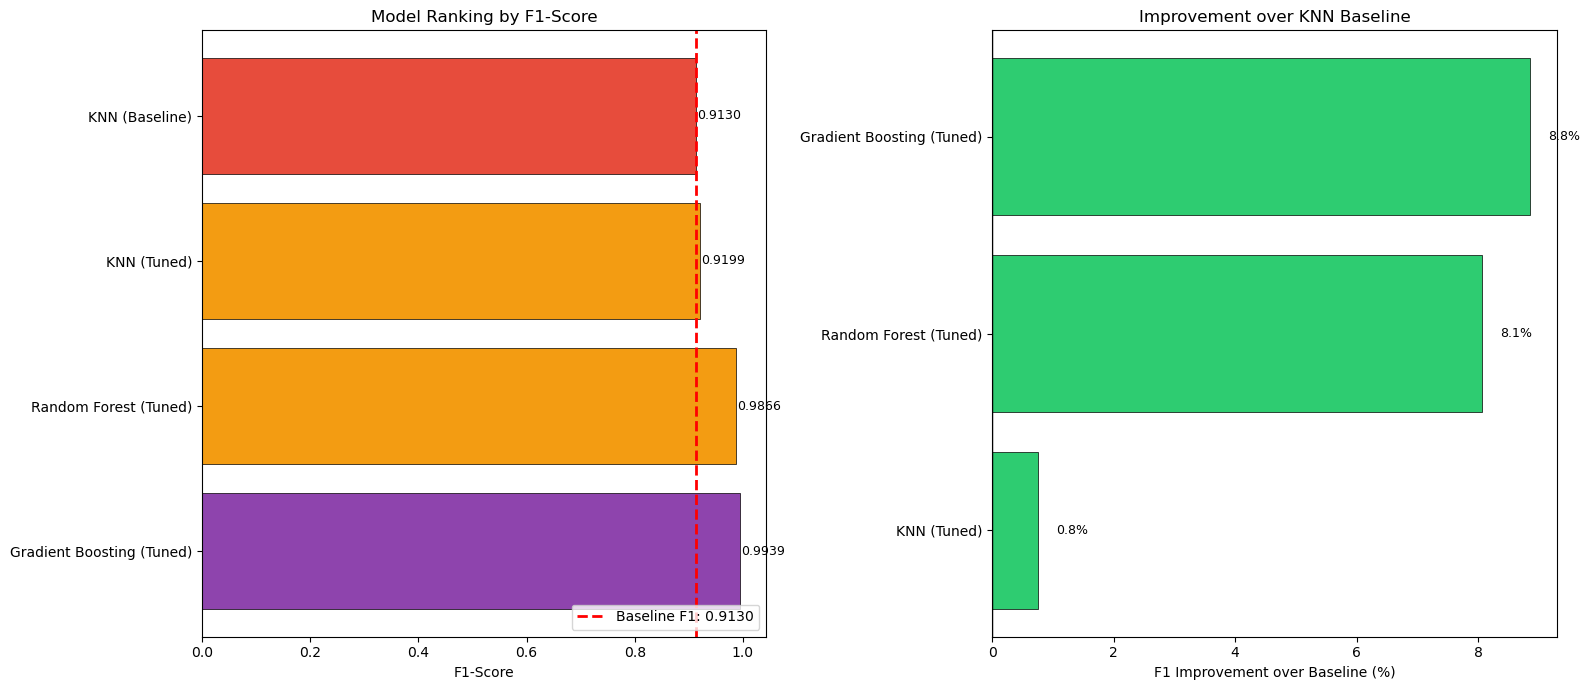

In [36]:
# --- Visualization 1: F1-Score ranking + Improvement ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Colour-code by type: baseline=red, individual models=orange, ensemble=purple
def bar_color(model_name):
    if 'Baseline' in model_name:
        return '#e74c3c'       # red
    if 'Gradient Boosting' in model_name or 'AdaBoost' in model_name:
        return '#8e44ad'       # purple (ensemble)
    return '#f39c12'           # orange (tuned individual)

colors = [bar_color(m) for m in final_df['Model']]

axes[0].barh(final_df['Model'], final_df['F1-Score'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].axvline(baseline_f1, color='red', linestyle='--', linewidth=2, label=f'Baseline F1: {baseline_f1:.4f}')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Model Ranking by F1-Score')
axes[0].legend(loc='lower right')
for i, v in enumerate(final_df['F1-Score']):
    axes[0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

# Improvement bar chart
imp = final_df[final_df['Model'] != 'KNN (Baseline)'].sort_values('F1 Improvement (%)', ascending=True)
colors_imp = ['#2ecc71' if v > 0 else '#e74c3c' for v in imp['F1 Improvement (%)']]
axes[1].barh(imp['Model'], imp['F1 Improvement (%)'], color=colors_imp, edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('F1 Improvement over Baseline (%)')
axes[1].set_title('Improvement over KNN Baseline')
for i, v in enumerate(imp['F1 Improvement (%)']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

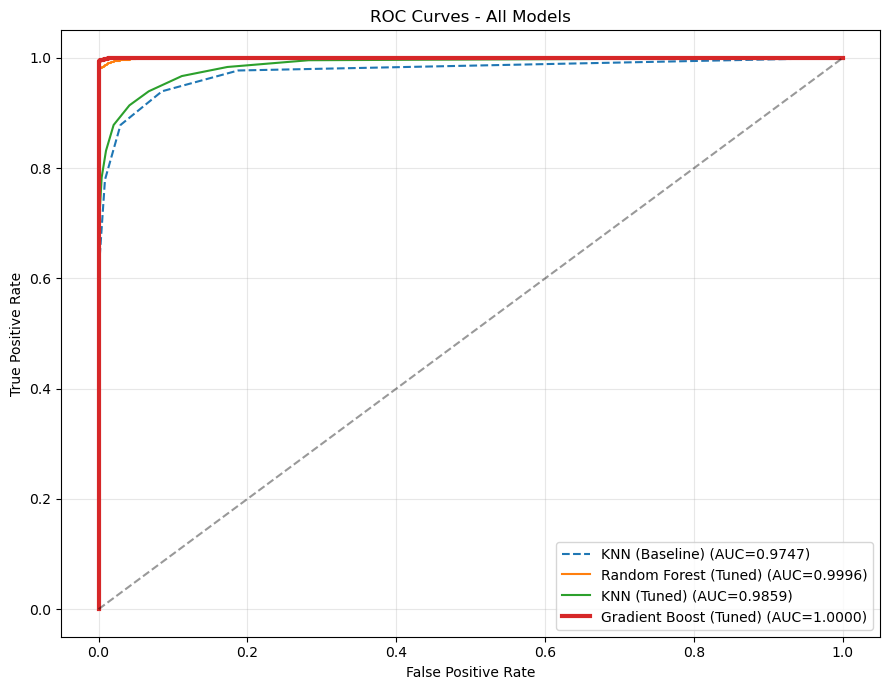

In [37]:
# --- Visualization 2: ROC Curves ---
fig, ax = plt.subplots(figsize=(9, 7))

roc_data = {
    'KNN (Baseline)':            y_prob_base,
    'Random Forest (Tuned)':     y_prob_rf,
    'KNN (Tuned)':               y_prob_knn,
    'Gradient Boost (Tuned)':    y_prob_gb,
}

for label, probs in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    lw = 3 if 'Gradient' in label or 'AdaBoost' in label else 1.5
    ls = '--' if 'Baseline' in label else '-'
    ax.plot(fpr, tpr, linewidth=lw, linestyle=ls, label=f'{label} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Models')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

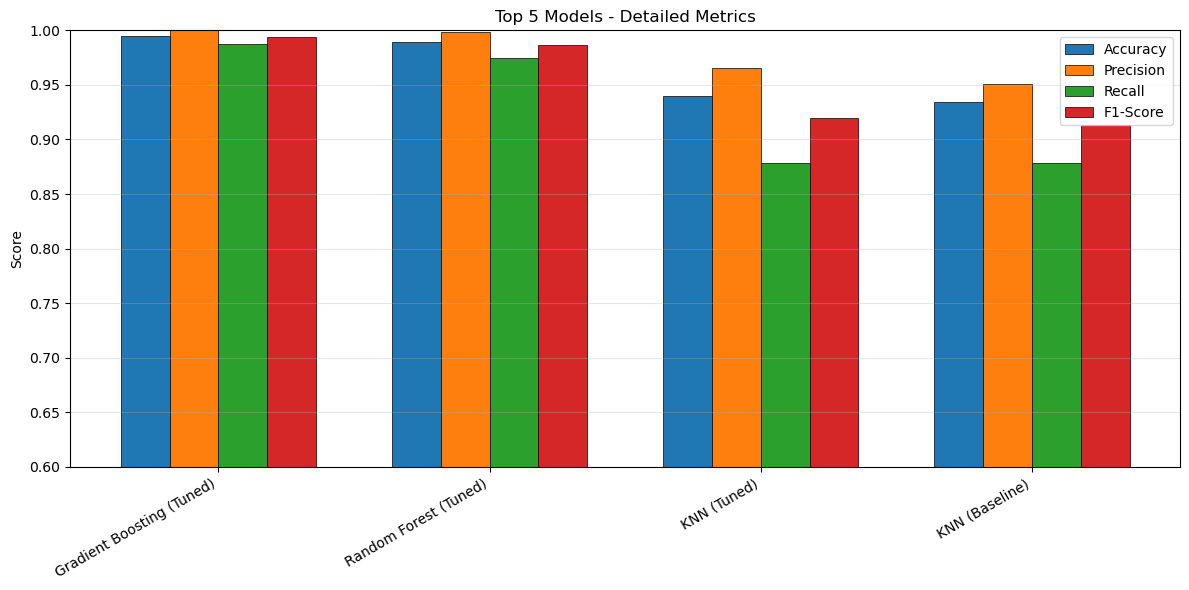

In [38]:
# --- Visualization 3: Multi-metric comparison for Top 5 ---
top5 = final_df.head(5)

fig, ax = plt.subplots(figsize=(12, 6))
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(top5))
width = 0.18

for i, m in enumerate(metrics_list):
    bars = ax.bar(x + i * width, top5[m], width, label=m, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(top5['Model'], rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Top 5 Models - Detailed Metrics')
ax.legend()
ax.set_ylim(0.6, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('top5_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

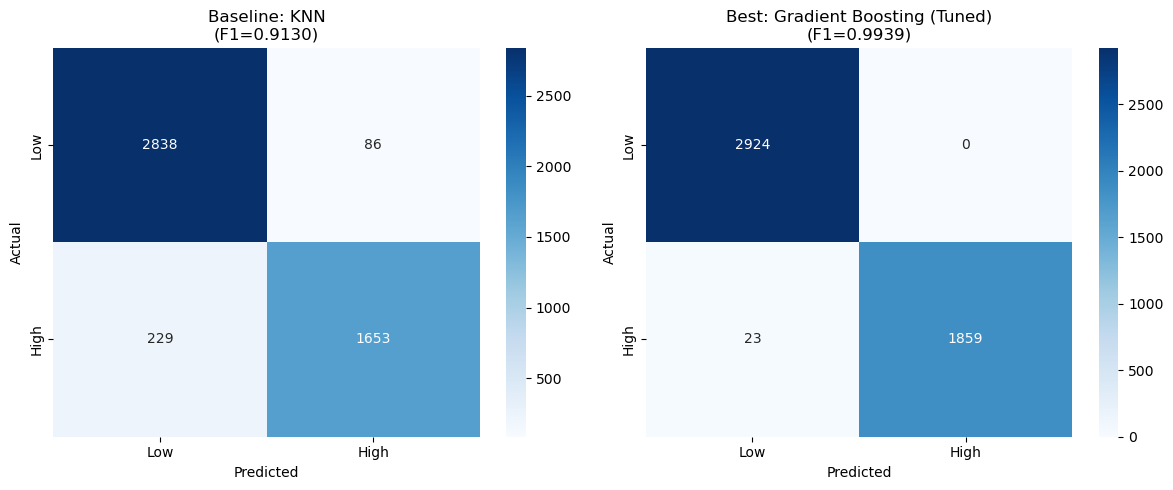

In [39]:
# --- Confusion matrices for Baseline vs Best ---
best_name = final_df.iloc[0]['Model']

# Determine best model predictions
best_preds_map = {
    'Random Forest (Tuned)': y_pred_rf,
    'KNN (Tuned)': y_pred_knn,
    'Gradient Boosting (Tuned)': y_pred_gb
}
y_pred_best = best_preds_map.get(best_name, y_pred_gb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, preds in [
    (axes[0], f'Baseline: KNN\n(F1={baseline_f1:.4f})', y_pred_base),
    (axes[1], f'Best: {best_name}\n(F1={final_df.iloc[0]["F1-Score"]:.4f})', y_pred_best),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_baseline_vs_best.png', dpi=150, bbox_inches='tight')
plt.show()

Feature Importance (Gradient Boosting Tuned)


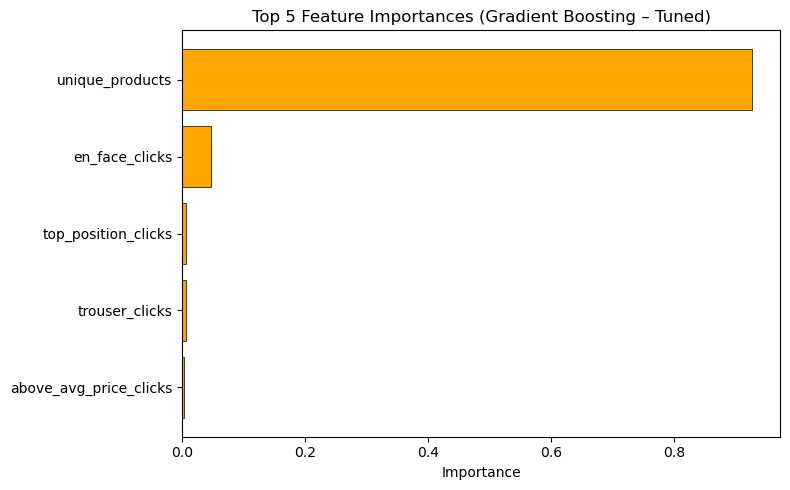


Top 5 Important Features:
               Feature  Importance
       unique_products    0.926653
        en_face_clicks    0.046985
   top_position_clicks    0.006277
        trouser_clicks    0.005763
above_avg_price_clicks    0.003630


In [40]:
# --- Feature Importance (from best Gradient Boosting tuned model) ---
print("Feature Importance (Gradient Boosting Tuned)")

# Get feature names from preprocessor
feat_names = numerical_features + list(
    preprocessor.named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features)
)

# Extract feature importances
importances = (
    gb_search.best_estimator_
    .named_steps['classifier']
    .feature_importances_
)

# Create importance DataFrame
imp_df = (
    pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
)

# Plot Top 5 features (slide-friendly)
fig, ax = plt.subplots(figsize=(8, 5))
top5 = imp_df.head(5)

ax.barh(
    top5['Feature'],
    top5['Importance'],
    edgecolor='black',
    color='orange',
    linewidth=0.5
)
ax.set_xlabel('Importance')
ax.set_title('Top 5 Feature Importances (Gradient Boosting – Tuned)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('gb_feature_importance_top5.png', dpi=150, bbox_inches='tight')
plt.show()

# Print Top 5 features
print("\nTop 5 Important Features:")
print(top5.to_string(index=False))

---
# Summary

In [41]:
best_row = final_df.iloc[0]

print("="*75)
print("SESSION ENGAGEMENT PREDICTION - SUMMARY")
print("="*75)
print(f"""
Task:        Binary Classification (High Engagement >= {ENGAGEMENT_THRESHOLD} clicks)
Dataset:     {len(session_df):,} sessions | {len(all_features)} features (9 categorical + 20 numerical)
Split:       80% train / 20% test (stratified)
Label:       {session_df['label'].mean()*100:.1f}% positive (high engagement)

BASELINE:    KNN (default params, k=5)
             Accuracy = {baseline_acc:.4f}  |  F1 = {baseline_f1:.4f}  |  AUC = {baseline_auc:.4f}

BEST MODEL:  {best_row['Model']}
             Accuracy = {best_row['Accuracy']:.4f}  |  F1 = {best_row['F1-Score']:.4f}  |  AUC = {best_row['ROC-AUC']:.4f}

IMPROVEMENT: +{best_row['F1 Improvement (%)']:.2f}% F1-Score over baseline
""")

print("Full results:")
print(final_df[['Model', 'Accuracy', 'F1-Score', 'ROC-AUC', 'F1 Improvement (%)']].to_string(index=False))

SESSION ENGAGEMENT PREDICTION - SUMMARY

Task:        Binary Classification (High Engagement >= 6 clicks)
Dataset:     24,026 sessions | 29 features (9 categorical + 20 numerical)
Split:       80% train / 20% test (stratified)
Label:       39.2% positive (high engagement)

BASELINE:    KNN (default params, k=5)
             Accuracy = 0.9345  |  F1 = 0.9130  |  AUC = 0.9747

BEST MODEL:  Gradient Boosting (Tuned)
             Accuracy = 0.9952  |  F1 = 0.9939  |  AUC = 1.0000

IMPROVEMENT: +8.85% F1-Score over baseline

Full results:
                    Model  Accuracy  F1-Score  ROC-AUC  F1 Improvement (%)
Gradient Boosting (Tuned)  0.995214  0.993852 0.999956                8.85
    Random Forest (Tuned)  0.989596  0.986552 0.999608                8.06
              KNN (Tuned)  0.940075  0.919866 0.985897                0.75
           KNN (Baseline)  0.934457  0.913007 0.974662                0.00
